# Benchmark Params
Benchmark notebook for training logs, curves, confusion matrix, and evaluation metrics

In [7]:
from pathlib import Path
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.trainer import train_baseline, build_model, prepare_ann_dataloaders, resolve_device
from src.utils import load_config

OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figure' / '02_training'
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'


## 1) Train baseline and load history

In [2]:
history = train_baseline(str(PROJECT_ROOT / 'configs' / 'baseline.yaml'))
config = load_config(PROJECT_ROOT / 'configs' / 'baseline.yaml')
model_name = config['models']['model_name'].lower()
history_path = OUTPUTS_DIR / f'{model_name}_history.yaml'
if history_path.exists():
    with open(history_path, 'r', encoding='utf-8') as f:
        history = yaml.safe_load(f)
history

---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 385428.45 examples/s]


Đã tải xong! Train: 11426 câu.
Epoch 1/10 | Loss: 0.4086 | Train Acc: 0.8552 | Val Acc: 0.8958
Epoch 2/10 | Loss: 0.2482 | Train Acc: 0.9136 | Val Acc: 0.9011
Epoch 3/10 | Loss: 0.1991 | Train Acc: 0.9315 | Val Acc: 0.8954
Epoch 4/10 | Loss: 0.1534 | Train Acc: 0.9473 | Val Acc: 0.9002
Epoch 5/10 | Loss: 0.1073 | Train Acc: 0.9634 | Val Acc: 0.8976
Epoch 6/10 | Loss: 0.0713 | Train Acc: 0.9781 | Val Acc: 0.8923
Epoch 7/10 | Loss: 0.0464 | Train Acc: 0.9867 | Val Acc: 0.9002
Epoch 8/10 | Loss: 0.0284 | Train Acc: 0.9905 | Val Acc: 0.8976
Epoch 9/10 | Loss: 0.0221 | Train Acc: 0.9926 | Val Acc: 0.8967
Epoch 10/10 | Loss: 0.0180 | Train Acc: 0.9941 | Val Acc: 0.8985
Saved model to: models/ann_baseline_model.pt
Saved vectorizer to: models/tfidf_vectorizer.pkl
Saved config/history to: outputs


{'train_loss': [0.408561260732529,
  0.24818570234558798,
  0.19910560565889923,
  0.15341027949812946,
  0.1073101755407463,
  0.07133527633480051,
  0.04635744339906956,
  0.028351935266982764,
  0.022074097860787695,
  0.01804367241948693],
 'val_loss': [0.2919939537015226,
  0.2886928768000669,
  0.30579154803935027,
  0.314227653046449,
  0.3790070459039675,
  0.4131119473216434,
  0.4580807704478502,
  0.5128085958874888,
  0.5506569664511416,
  0.6140497121959925],
 'train_acc': [0.8551580789847938,
  0.9135761951646428,
  0.9315173394595777,
  0.9472705393283011,
  0.9633519308609562,
  0.9781205557378843,
  0.9866535390001094,
  0.9904824417459797,
  0.9925609889508806,
  0.9940925500492287],
 'val_acc': [0.8958424507658643,
  0.9010940919037199,
  0.8954048140043763,
  0.900218818380744,
  0.8975929978118162,
  0.8923413566739606,
  0.900218818380744,
  0.8975929978118162,
  0.8967177242888402,
  0.8984682713347921]}

## 2) Plot training curves (Loss and Accuracy)

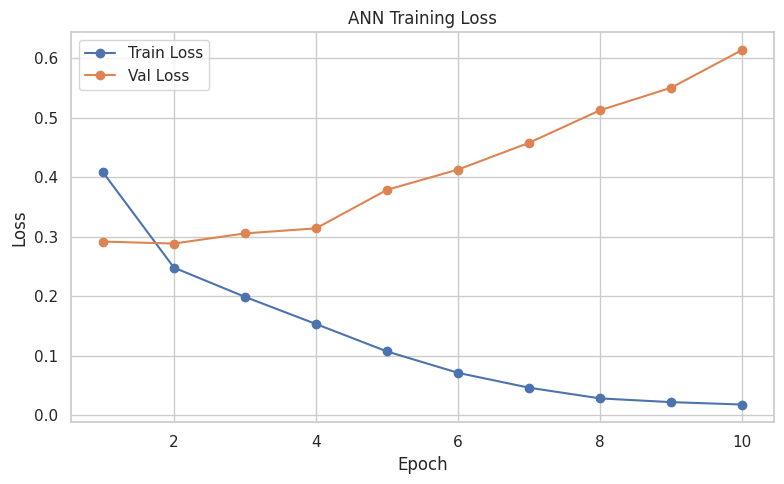

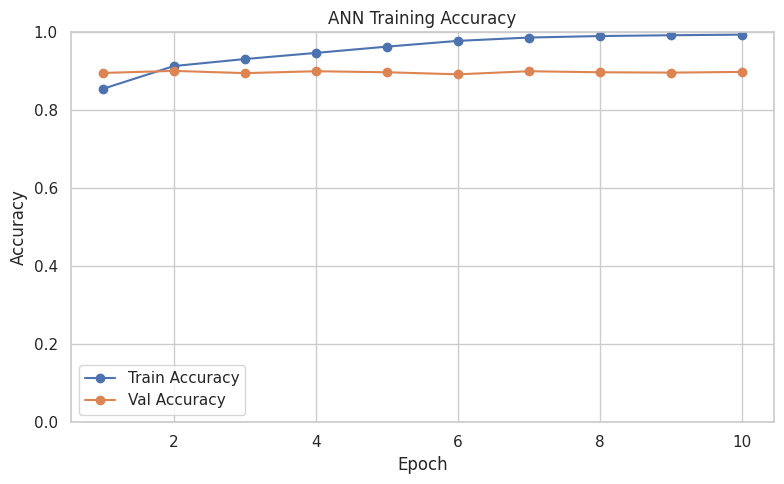

Saved: /home/coronny/sentiment_analysis/reports/figure/ann_feature1000_dropout0.2_loss.png
Saved: /home/coronny/sentiment_analysis/reports/figure/ann_feature1000_dropout0.2_accuracy.png


In [3]:
epochs = np.arange(1, len(history['train_loss']) + 1)
dropout_text = str(config['models']['ann']['dropout'])
max_features = config['data'].get('max_features', config['data'].get('max_Features'))
base_name = f"{model_name}_feature{max_features}_dropout{dropout_text}"

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
plt.title(f'{model_name.upper()} Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
loss_path = OUTPUT_FIGURE_DIR / f'{base_name}_loss.png'
plt.tight_layout()
plt.savefig(loss_path, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_acc'], marker='o', label='Train Accuracy')
plt.plot(epochs, history['val_acc'], marker='o', label='Val Accuracy')
plt.title(f'{model_name.upper()} Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
acc_path = OUTPUT_FIGURE_DIR / f'{base_name}_accuracy.png'
plt.tight_layout()
plt.savefig(acc_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {loss_path}')
print(f'Saved: {acc_path}')

## 3) Evaluate best checkpoint on validation set

In [4]:
device = resolve_device(config['training']['device'])
_, val_loader, _ = prepare_ann_dataloaders(config)
model = build_model(config).to(device)
best_ckpt_path = CHECKPOINTS_DIR / f'{model_name}_best_model.pt'
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.extend(preds.tolist())
        all_true.extend(y_batch.numpy().tolist())

acc = accuracy_score(all_true, all_pred)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_pred, average='macro', zero_division=0)
metrics = {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}
metrics

## 4) Plot confusion matrix

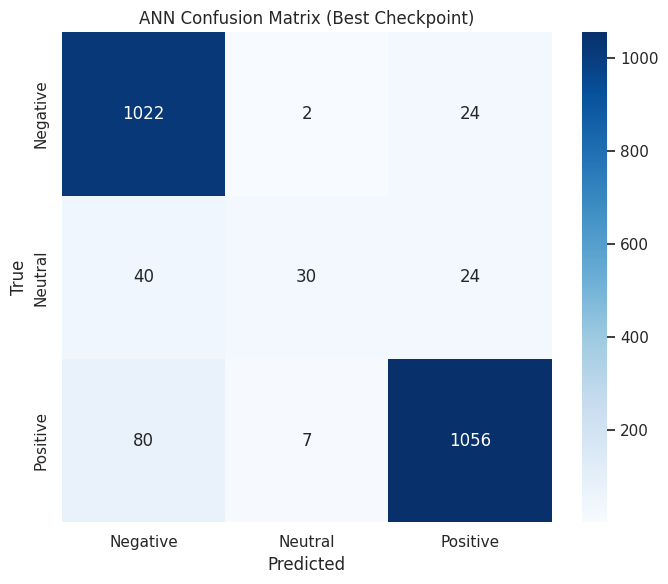

Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_confusion_matrix.png


In [8]:
label_names = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'{model_name.upper()} Confusion Matrix (Best Checkpoint)')
plt.xlabel('Predicted')
plt.ylabel('True')
cm_path = OUTPUT_FIGURE_DIR / f'{model_name}_confusion_matrix.png'
plt.tight_layout()
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

## 5) Plot metrics bar chart

/tmp/ipykernel_11454/4030337518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


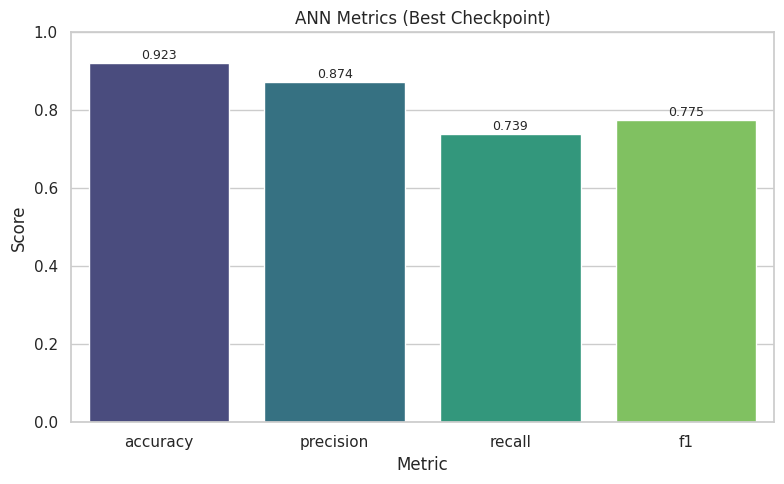

Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_metrics.png


In [9]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.ylim(0, 1)
plt.title(f'{model_name.upper()} Metrics (Best Checkpoint)')
plt.xlabel('Metric')
plt.ylabel('Score')
metric_path = OUTPUT_FIGURE_DIR / f'{model_name}_metrics.png'
plt.tight_layout()
plt.savefig(metric_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {metric_path}')